```text
Expected Loss analysis
├── Import & Setup
├── Expected Loss - on PD
└── Expected Loss - on PD x LGD (HeatMap)
```

# Expected Loss analysis

#### Import & Setup 

In [1]:
# Init work dir

from pathlib import Path
import sys
PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [ ]:
# Standard modules

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns

# Framework

from src.decisioning import display_el
from src.modelling import apply_pipe
from src.plots import my_el_plot, my_el_heatmap
from src.preprocessing import my_input_load, ReplaceMinusOne

# Configuration

pd.set_option("display.max_columns", None)
pd.set_option("display.width", None)
pd.set_option("display.expand_frame_repr", False)
from sklearn import set_config; set_config(transform_output="pandas")

In [3]:
# import pipeline

import joblib
pipeline = joblib.load("../models/PIPELINE_ver_011_cal_shift-test.pkl")

In [4]:
# load input file

this_dataset = my_input_load(2019, 2020)
#this_dataset.info(show_counts=True, verbose=True)

In [5]:
# apply pipeline

this_dataset_applied = apply_pipe(this_dataset, pipeline, sensitivity_lgd=True)

EmploymentStatus: replacing 48,446 values of -1 with NaN
MaritalStatus: replacing 48,446 values of -1 with NaN
OccupationArea: replacing 48,446 values of -1 with NaN
UseOfLoan: replacing 48,446 values of -1 with NaN


## Expected Loss - on PD

In [6]:
# check dataset for use

this_dataset_applied[["PD", "LossGivenDefault", "Amount", "EL", "EL_10", "EL_15", "EL_25", "EL_90"]].head(10)

,PD,LossGivenDefault,Amount,EL,EL_10,EL_15,EL_25,EL_90
0,0.244017,0.510233,4250.0,529.147768,103.707084,155.560625,259.267709,933.363752
1,0.137387,0.579090,6800.0,541.005361,93.423415,140.135123,233.558538,840.810736
2,0.234492,0.561591,1485.0,195.557215,34.821995,52.232993,87.054988,313.397956
3,0.236467,0.487083,3400.0,391.608296,80.398701,120.598052,200.996754,723.588313
4,0.159286,0.512912,530.0,43.300729,8.442135,12.663203,21.105339,75.979219
5,0.163061,0.512912,1165.0,97.435765,18.996584,28.494876,47.491460,170.969256
6,0.191252,0.459668,850.0,74.725581,16.256422,24.384633,40.641055,146.307799
7,0.334685,0.641801,4250.0,912.904950,142.241200,213.361801,355.603001,1280.170804
8,0.153418,0.621970,9035.0,862.133354,138.613304,207.919957,346.533261,1247.519739
9,0.117979,0.499905,955.0,56.324161,11.266970,16.900455,28.167425,101.402730


In [7]:
# EL by PD bin

bins = [0, 0.05, 0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]

#### EL (LGD from data)

total_EL = this_dataset_applied["EL"].sum()
mean_LGD = this_dataset_applied["LossGivenDefault"].mean()
print("-" * 50)
print('OVERALL STATS (LGD from data):')
print(f"EL sum = {total_EL:,.0f}")
print(f"LGD mean = {mean_LGD:,.2%}")
print("-" * 50)
# evaluation data and bin
df_eval = this_dataset_applied[["PD", "EL"]].copy()
df_eval["prob_bin"] = pd.cut(df_eval["PD"], bins=bins)
# aggregation
table_EL = (
    df_eval.groupby("prob_bin", observed=False)
    .agg(
        Count  = ("PD", "count"),
        Avg_PD = ("PD", "mean"),
        Sum_EL = ("EL", "sum")
    )
)
# EL share
table_EL["Share_EL"] = table_EL["Sum_EL"] / total_EL
# display EL table
display_table_EL = table_EL.T
display_el(display_table_EL)

#### EL (LGD x%)

EL_X = "EL_15"

total_EL_x = this_dataset_applied[EL_X].sum()
print("-" * 50)
print('OVERALL STATS (LGD 15%):')
print(f"EL sum = {total_EL_x:,.0f}")
print(f"LGD mean = {0.15:,.2%}")
print("-" * 50)
# evaluation data and bin
df_eval_x = this_dataset_applied[["PD", EL_X]].copy()
df_eval_x["prob_bin"] = pd.cut(df_eval_x["PD"], bins=bins)
# aggregation
table_EL_x = (
    df_eval_x.groupby("prob_bin", observed=False)
    .agg(
        Count  = ("PD", "count"),
        Avg_PD = ("PD", "mean"),
        Sum_EL = (EL_X, "sum")
    )
)
# EL share
table_EL_x["Share_EL"] = table_EL_x["Sum_EL"] / total_EL_x
# display EL table
display_table_EL_x = table_EL_x.T
display_el(display_table_EL_x)

--------------------------------------------------
OVERALL STATS (LGD from data):
EL sum = 3,008,987
LGD mean = 15.23%
--------------------------------------------------
--------------------------------------------------


prob_bin,"(0.0, 0.05]","(0.05, 0.1]","(0.1, 0.15]","(0.15, 0.2]","(0.2, 0.25]","(0.25, 0.3]","(0.3, 0.35]","(0.35, 0.4]","(0.4, 0.5]","(0.5, 0.6]","(0.6, 0.7]","(0.7, 0.8]","(0.8, 0.9]","(0.9, 1.0]"
Count,738,"10,459","16,896","11,279","5,127","2,185","1,066",483,193,20,0,0,0,0
Avg_PD,4.25%,8.04%,12.46%,17.21%,22.14%,27.18%,32.24%,37.06%,43.18%,53.21%,nan%,nan%,nan%,nan%
Sum_EL,"6,725","239,400","749,712","829,972","541,623","301,618","195,317","103,793","37,036","3,791",0,0,0,0
Share_EL,0.22%,7.96%,24.92%,27.58%,18.00%,10.02%,6.49%,3.45%,1.23%,0.13%,0.00%,0.00%,0.00%,0.00%


--------------------------------------------------
--------------------------------------------------
OVERALL STATS (LGD 15%):
EL sum = 2,898,600
LGD mean = 15.00%
--------------------------------------------------
--------------------------------------------------


prob_bin,"(0.0, 0.05]","(0.05, 0.1]","(0.1, 0.15]","(0.15, 0.2]","(0.2, 0.25]","(0.25, 0.3]","(0.3, 0.35]","(0.35, 0.4]","(0.4, 0.5]","(0.5, 0.6]","(0.6, 0.7]","(0.7, 0.8]","(0.8, 0.9]","(0.9, 1.0]"
Count,738,"10,459","16,896","11,279","5,127","2,185","1,066",483,193,20,0,0,0,0
Avg_PD,4.25%,8.04%,12.46%,17.21%,22.14%,27.18%,32.24%,37.06%,43.18%,53.21%,nan%,nan%,nan%,nan%
Sum_EL,"6,958","226,312","689,189","762,061","538,178","311,459","193,437","106,377","56,629","8,000",0,0,0,0
Share_EL,0.24%,7.81%,23.78%,26.29%,18.57%,10.75%,6.67%,3.67%,1.95%,0.28%,0.00%,0.00%,0.00%,0.00%


--------------------------------------------------


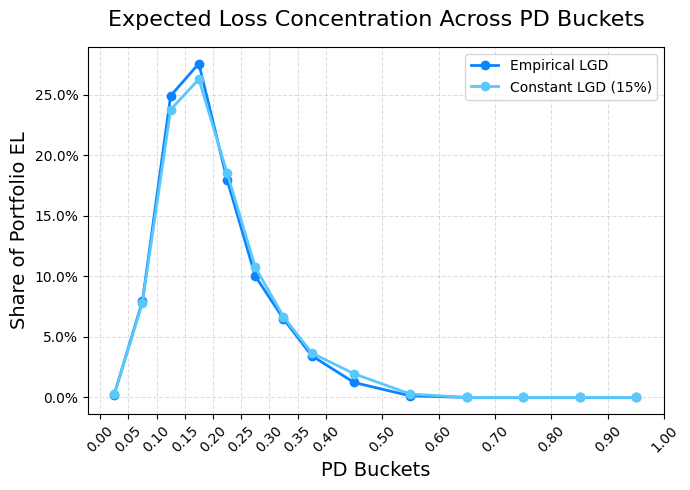

In [8]:
# plot: EL concentration across PD buckets

my_el_plot(table_EL, table_EL_x)

## Expected Loss - on PD x LGD (HeatMap)

<class 'pandas.DataFrame'>
RangeIndex: 48446 entries, 0 to 48445
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   PD                48446 non-null  float64
 1   LossGivenDefault  48446 non-null  float64
 2   Amount            48446 non-null  float64
 3   EL                48446 non-null  float64
dtypes: float64(4)
memory usage: 1.5 MB
None
             ≤10%    10–12%    12–15%    15–20%      ≥20%
30–50%   0.029282  0.043009  0.058625  0.085654  0.145875
50–70%   0.035146  0.072426  0.105585  0.144007  0.259950
70–100%  0.000582  0.001784  0.004046  0.006260  0.007769


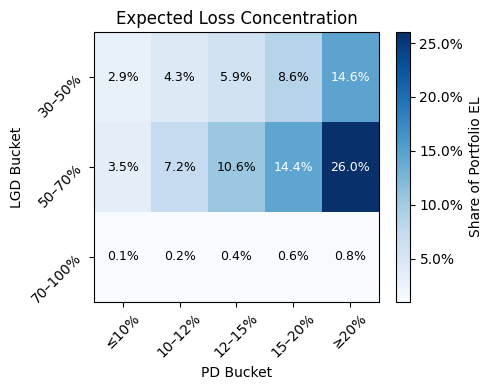

In [ ]:
# plot: EL heatmap on PD,LGD

df = this_dataset_applied[["PD", "LossGivenDefault", "Amount", "EL"]]
my_el_heatmap(df)